# Get the model

In [6]:
import pandas as pd

df = pd.read_csv('../../../datasets/Youtube-Spam-Dataset.csv')
df.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1


# Preprocessing

**The target "CLASS"**
- 0: Means not_spam
- 1: Means spam

### Null Values

In [7]:
print(f"Null values in the dataset: {df.isnull().sum()}")

Null values in the dataset: COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
VIDEO_NAME      0
CLASS           0
dtype: int64


### Se the balanced of data

In [8]:
df['CLASS'].value_counts()

CLASS
1    1005
0     951
Name: count, dtype: int64

### Vectorization the features (text)

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = cv.fit_transform(df['CONTENT'])


In [10]:
y = df['CLASS']
print(X.shape, y.shape)

(1956, 4454) (1956,)


# Split the data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, stratify= y)


print(f'Shape of train: {X_train.shape}, {y_train.shape}')
print(f"Shape of test: {X_test.shape}, {y_test.shape}")

Shape of train: (1564, 4454), (1564,)
Shape of test: (392, 4454), (392,)


# Get the models

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mnb = MultinomialNB()


# Train the model

Train Metrics: Accuracy:0.965 | F1: 0.965 | Precision: 0.965 | Recall: 0.965|
Test Metrics: Accuracy:0.941 | F1: 0.941 | Precision: 0.941 | Recall: 0.941 | 
Confusion Matriz:


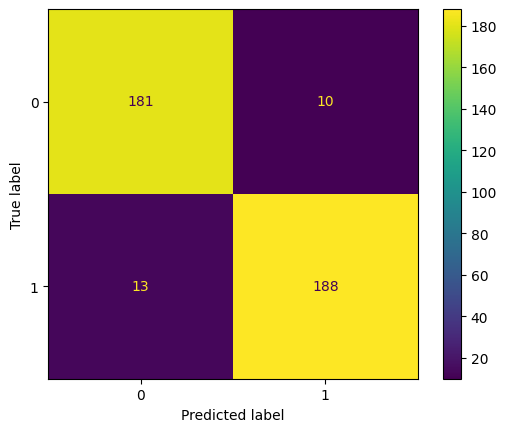

Best Parameters: {'alpha': 1.0, 'fit_prior': False}
Best Score (CV F1-Macro): 0.929


In [13]:
parameters = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 10.0],
    'fit_prior': [True, False]
}

grid = GridSearchCV(mnb, parameters, cv=5)
grid.fit(X_train, y_train)


# See the metrics (val test)
y_preds_train = grid.predict(X_train)
accuracy = accuracy_score(y_train, y_preds_train)
f1 = f1_score(y_train, y_preds_train, average = 'macro')
precision = precision_score(y_train, y_preds_train, average = 'macro')
recall = recall_score(y_train, y_preds_train, average = 'macro')
print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
y_preds_test = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_preds_test)
f1 = f1_score(y_test, y_preds_test, average = 'macro')
precision = precision_score(y_test, y_preds_test, average = 'macro')
recall = recall_score(y_test, y_preds_test, average = 'macro')
confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
plt.show()

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score (CV F1-Macro): {grid.best_score_:.3f}")




In [14]:
model = grid.best_estimator_

In [15]:
# (SPAM - YouTube Comments in English)
youtube_spam_english_tests = [
    "I made $3,000 in just one week thanks to Mrs. Linda's trading platform! Reach her on WhatsApp: +1 (555) 012-3456 📈💰",
    "First 100 people to subscribe to my channel get a shoutout in my next video! #Sub4Sub #RoadTo10k",
    "GIVEAWAY ALERT! You've won a brand new MacBook Pro. Visit the link in my bio to claim your prize before it expires!!",
    "Does anyone else think @CryptoExpert is a genius? His signals helped me quit my job. Check his Telegram @SuccessSignals.",
    "If you're reading this, I hope you have an amazing day! Please check out my music, I'm a 14-year-old producer trying to make it big.",
    "CHANNEL ADMIN: Congratulations! You were randomly selected. Contact us on Telegram @YoutubeRewards_2026 to verify.",
    "WANT MORE VIEWS? Get 1,000 subscribers and 4,000 watch hours instantly. Safe and organic! Visit: www.boost-my-channel.com",
    "The secret trick to losing belly fat in 3 days! No exercise needed. Check the pinned comment for the link! 😱👇",
    "I'm a small creator and I put my heart into my videos. It would mean the world if you could just take 10 seconds to look at my channel.",
    "Make $500/day just by watching videos! No experience required. DM me for info or join the link in the description."
]

# (HAM - YouTube Comments in English)
youtube_ham_tests = [
    "I've been looking for a tutorial on this for ages. Thank you for the clear explanation!",
    "04:25 - This is exactly where I was getting stuck. Great catch, man.",
    "Does anyone know what song is playing in the background at the start of the video?",
    "I tried this recipe last night and it turned out amazing! My whole family loved it.",
    "Honestly, this channel is so underrated. The production quality is top-notch.",
    "I disagree with the point about the camera specs, but I see where you're coming from.",
    "Can you do a follow-up video on how to set up the software for Mac users?",
    "Lol that transition caught me off guard. Editing is getting better and better!",
    "I’ve watched this five times now and I still find something new every time. So helpful.",
    "Wait, did he actually manage to finish the challenge? That was insane!"
]

In [16]:
print("Ham tests\n")
for text in youtube_ham_tests:
    text = cv.transform([text])
    predict = model.predict(text)
    if predict[0] == 0:
        print(f"You text is ham")
    else:
        print(f'You text is spam')

print('=' * 50)
print("Spam Tests\n")

for text in youtube_spam_english_tests:
    text = cv.transform([text])
    predict = model.predict(text)
    if predict[0] == 0:
        print(f"You text is ham")
    else:
        print(f'You text  spam')





Ham tests

You text is spam
You text is ham
You text is ham
You text is spam
You text is ham
You text is ham
You text is spam
You text is ham
You text is ham
You text is ham
Spam Tests

You text  spam
You text  spam
You text  spam
You text  spam
You text  spam
You text  spam
You text  spam
You text  spam
You text  spam
You text  spam


In [17]:
import joblib

# Salve the file for our app use
joblib.dump(model, 'model_nb.pkl') 
joblib.dump(cv, 'vectorizer.pkl')

['vectorizer.pkl']

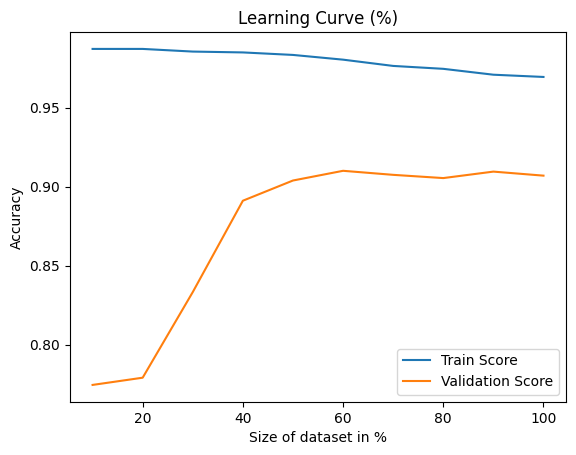

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(np.linspace(10, 100, 10), train_mean, label='Train Score')
plt.plot(np.linspace(10, 100, 10), test_mean, label='Validation Score')

plt.xlabel('Size of dataset in %')
plt.ylabel('Accuracy')
plt.title('Learning Curve (%)')
plt.legend()
plt.show()